# 📊 Unemployment Analysis in India
## Using NumPy & Pandas — Data Science Internship Project

**Dataset:** Unemployment in India (Kaggle)  
**Tools:** Python · NumPy · Pandas · Matplotlib · Seaborn  
**Period:** May 2019 – June 2020 (includes COVID-19 impact)

---


## 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Data Cleaning & Preprocessing](#3-data-cleaning)
4. [Exploratory Data Analysis (EDA) with Pandas](#4-eda-pandas)
5. [NumPy-Based Statistical Analysis](#5-numpy-stats)
6. [Region-wise Analysis](#6-region-analysis)
7. [Rural vs Urban Analysis](#7-rural-urban)
8. [COVID-19 Impact Analysis](#8-covid-impact)
9. [Correlation Analysis](#9-correlation)
10. [Visualizations](#10-visualizations)
11. [Key Insights & Conclusions](#11-conclusions)


## 1. Import Libraries <a id='1-import-libraries'></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Plot Style ──────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"    : 120,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

print("✅ Libraries imported successfully")
print(f"   NumPy  version : {np.__version__}")
print(f"   Pandas version : {pd.__version__}")


✅ Libraries imported successfully
   NumPy  version : 2.4.3
   Pandas version : 3.0.1


## 2. Load Dataset <a id='2-load-dataset'></a>

In [4]:
df = pd.read_csv("unemployeementinindia.csv")

# Strip column names
df.columns = df.columns.str.strip()

print("Shape :", df.shape)
print("\nColumns:")
for c in df.columns:
    print("  •", c)
df.head(10)


Shape : (768, 7)

Columns:
  • Region
  • Date
  • Frequency
  • Estimated Unemployment Rate (%)
  • Estimated Employed
  • Estimated Labour Participation Rate (%)
  • Area


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [5]:
print("── DataFrame Info ──────────────────────────────────────")
df.info()


── DataFrame Info ──────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


## 3. Data Cleaning & Preprocessing <a id='3-data-cleaning'></a>
Steps performed:
- Rename columns to snake_case
- Strip whitespace from all string columns
- Parse `Date` to datetime
- Convert numeric columns
- Drop empty rows
- Engineer new time features


In [6]:
# 3.1  Rename columns
df.columns = [
    "Region", "Date", "Frequency",
    "Unemployment_Rate", "Employed",
    "Labour_Participation_Rate", "Area"
]

# 3.2  Strip whitespace from string columns
str_cols = df.select_dtypes("object").columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# 3.3  Drop fully-empty rows
df.dropna(how="all", inplace=True)

# 3.4  Parse Date
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# 3.5  Numeric conversion
for col in ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3.6  Drop rows with NaN in key columns
df.dropna(subset=["Unemployment_Rate", "Employed", "Labour_Participation_Rate"], inplace=True)

# 3.7  Feature engineering
df["Year"]       = df["Date"].dt.year
df["Month_Num"]  = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"]    = df["Date"].dt.quarter
df["Year_Month"] = df["Date"].dt.to_period("M")

print(f"✅ Clean shape : {df.shape}")
print(f"   Date range  : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"   Regions     : {df['Region'].nunique()}")
print(f"   Area types  : {df['Area'].unique()}")
df.head()


✅ Clean shape : (740, 12)
   Date range  : 2019-05-31  →  2020-06-30
   Regions     : 28
   Area types  : <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month_Num,Month_Name,Quarter,Year_Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May,2,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June,2,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July,3,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August,3,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September,3,2019-09


In [7]:
print("── Missing Values ──────────────────────────────────────")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "  No missing values ✅")


── Missing Values ──────────────────────────────────────
  No missing values ✅


## 4. Exploratory Data Analysis (EDA) with Pandas <a id='4-eda-pandas'></a>

In [8]:
# 4.1  Descriptive statistics
print("── Descriptive Statistics ──────────────────────────────")
df[["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]].describe().round(2)


── Descriptive Statistics ──────────────────────────────


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


In [9]:
# 4.2  Value counts — Area type
print("── Record Count by Area ────────────────────────────────")
print(df["Area"].value_counts())

print("\n── Record Count by Year ────────────────────────────────")
print(df["Year"].value_counts().sort_index())


── Record Count by Area ────────────────────────────────
Area
Urban    381
Rural    359
Name: count, dtype: int64

── Record Count by Year ────────────────────────────────
Year
2019    430
2020    310
Name: count, dtype: int64


In [10]:
# 4.3  Average unemployment by Region (Pandas groupby)
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
    .rename(columns={"mean":"Avg", "median":"Median",
                     "std":"Std_Dev", "min":"Min", "max":"Max"})
    .sort_values("Avg", ascending=False)
)
print("── Average Unemployment Rate by Region ─────────────────")
region_avg


── Average Unemployment Rate by Region ─────────────────


,Avg,Median,Std_Dev,Min,Max
Region,,,,,
Tripura,28.35,27.31,6.06,14.71,43.64
Haryana,26.28,25.06,7.80,14.54,46.89
Jharkhand,20.58,17.28,16.67,5.01,70.17
Bihar,18.92,15.01,12.63,8.87,58.77
Himachal Pradesh,18.54,18.35,9.61,1.12,50.00
Delhi,16.50,15.02,6.79,9.33,45.78
Jammu & Kashmir,16.19,16.00,5.51,2.22,24.06
Chandigarh,15.99,17.51,5.51,7.22,22.05
Rajasthan,14.06,13.66,5.93,4.03,35.53


In [11]:
# 4.4  Monthly national average (Pandas pivot)
monthly_nat = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .reset_index()
    .sort_values("Date")
)
print("── Monthly National Average (first 10 rows) ────────────")
monthly_nat.head(10)


── Monthly National Average (first 10 rows) ────────────


,Date,Unemployment_Rate
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731
5,2019-10-31,9.900909
6,2019-11-30,9.868364
7,2019-12-31,9.497358
8,2020-01-31,9.950755
9,2020-02-29,9.964717


In [12]:
# 4.5  Top 5 states with highest unemployment — using Pandas nlargest
top5 = region_avg["Avg"].nlargest(5)
bottom5 = region_avg["Avg"].nsmallest(5)

print(" Top 5 Highest Unemployment States:")
print(top5.to_string())
print("\n Top 5 Lowest Unemployment States:")
print(bottom5.to_string())


 Top 5 Highest Unemployment States:
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54

 Top 5 Lowest Unemployment States:
Region
Meghalaya      4.80
Odisha         5.66
Assam          6.43
Uttarakhand    6.58
Gujarat        6.66


In [13]:
# 4.6  Crosstab — Area × Year
ct = pd.crosstab(df["Year"], df["Area"],
                 values=df["Unemployment_Rate"], aggfunc="mean").round(2)
print("── Avg Unemployment Rate  (Year × Area) ────────────────")
ct


── Avg Unemployment Rate  (Year × Area) ────────────────


Area,Rural,Urban
Year,,
2019,8.04,10.67
2020,13.47,16.65


## 5. NumPy-Based Statistical Analysis <a id='5-numpy-stats'></a>

In [14]:
# Extract NumPy array
ur = df["Unemployment_Rate"].values   # ndarray
lp = df["Labour_Participation_Rate"].values
em = df["Employed"].values

print("═" * 55)
print("  NumPy Statistical Analysis — Unemployment Rate")
print("═" * 55)
print(f"  Count         : {ur.size}")
print(f"  Sum           : {np.sum(ur):.2f}")
print(f"  Mean          : {np.mean(ur):.4f} %")
print(f"  Median        : {np.median(ur):.4f} %")
print(f"  Std Dev       : {np.std(ur):.4f}")
print(f"  Variance      : {np.var(ur):.4f}")
print(f"  Min           : {np.min(ur):.2f} %  → {df.loc[df['Unemployment_Rate'].idxmin(), 'Region']}")
print(f"  Max           : {np.max(ur):.2f} %  → {df.loc[df['Unemployment_Rate'].idxmax(), 'Region']}")
print(f"  Range         : {np.ptp(ur):.2f}")
print(f"  25th pctile   : {np.percentile(ur, 25):.2f} %")
print(f"  75th pctile   : {np.percentile(ur, 75):.2f} %")
print(f"  IQR           : {np.percentile(ur, 75) - np.percentile(ur, 25):.2f}")
print(f"  Skewness (np) : {float(pd.Series(ur).skew()):.4f}")
print(f"  Kurtosis (np) : {float(pd.Series(ur).kurt()):.4f}")


═══════════════════════════════════════════════════════
  NumPy Statistical Analysis — Unemployment Rate
═══════════════════════════════════════════════════════
  Count         : 740
  Sum           : 8723.08
  Mean          : 11.7879 %
  Median        : 8.3500 %
  Std Dev       : 10.7141
  Variance      : 114.7909
  Min           : 0.00 %  → Assam
  Max           : 76.74 %  → Puducherry
  Range         : 76.74
  25th pctile   : 4.66 %
  75th pctile   : 15.89 %
  IQR           : 11.23
  Skewness (np) : 2.2179
  Kurtosis (np) : 7.4720


In [15]:
# 5.2  NumPy Percentile Breakdown
pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]
print("── Percentile Breakdown ────────────────────────────────")
for p in pcts:
    print(f"  P{p:>2}  : {np.percentile(ur, p):.2f} %")


── Percentile Breakdown ────────────────────────────────
  P10  : 2.55 %
  P20  : 4.08 %
  P30  : 5.22 %
  P40  : 6.59 %
  P50  : 8.35 %
  P60  : 10.84 %
  P70  : 13.82 %
  P80  : 18.54 %
  P90  : 25.25 %
  P95  : 31.92 %
  P99  : 51.95 %


In [16]:
# 5.3  NumPy — Pearson Correlation Matrix
num_arr = np.column_stack([ur, lp, em])
corr_np = np.corrcoef(num_arr.T)
labels  = ["Unemployment", "Labour_Part_Rate", "Employed"]

print("── NumPy Correlation Matrix ────────────────────────────")
corr_df = pd.DataFrame(corr_np, index=labels, columns=labels)
print(corr_df.round(4))


── NumPy Correlation Matrix ────────────────────────────
                  Unemployment  Labour_Part_Rate  Employed
Unemployment            1.0000            0.0026   -0.2229
Labour_Part_Rate        0.0026            1.0000    0.0113
Employed               -0.2229            0.0113    1.0000


In [17]:
# 5.4  NumPy — Z-Score (detect extreme outliers)
z_scores = (ur - np.mean(ur)) / np.std(ur)
outlier_mask = np.abs(z_scores) > 2.5
outliers = df[outlier_mask][["Region", "Date", "Area", "Unemployment_Rate"]].copy()
outliers["Z_Score"] = z_scores[outlier_mask].round(3)
outliers = outliers.sort_values("Unemployment_Rate", ascending=False)

print(f"── Extreme Outliers  (|Z| > 2.5) : {outlier_mask.sum()} rows ──────")
outliers.head(15)


── Extreme Outliers  (|Z| > 2.5) : 20 rows ──────


,Region,Date,Area,Unemployment_Rate,Z_Score
627,Puducherry,2020-04-30,Urban,76.74,6.062
628,Puducherry,2020-05-31,Urban,75.00,5.900
242,Puducherry,2020-04-30,Rural,74.51,5.854
531,Jharkhand,2020-05-31,Urban,70.17,5.449
530,Jharkhand,2020-04-30,Urban,61.48,4.638
412,Bihar,2020-04-30,Urban,58.77,4.385
145,Jharkhand,2020-05-31,Rural,55.10,4.043
287,Tamil Nadu,2020-04-30,Rural,53.19,3.864
507,Himachal Pradesh,2020-05-31,Urban,50.00,3.567
38,Bihar,2020-05-31,Rural,47.26,3.311


In [18]:
# 5.5  NumPy — Moving Average (7-point) on national monthly series
monthly_vals = monthly_nat["Unemployment_Rate"].values
moving_avg   = np.convolve(monthly_vals, np.ones(3)/3, mode="same")

print("── 3-Point Moving Average (first 10 values) ────────────")
for raw, ma in list(zip(monthly_vals[:10], moving_avg[:10])):
    print(f"  Raw: {raw:6.2f}%   MA3: {ma:6.2f}%")


── 3-Point Moving Average (first 10 values) ────────────
  Raw:   8.87%   MA3:   6.06%
  Raw:   9.30%   MA3:   9.07%
  Raw:   9.03%   MA3:   9.33%
  Raw:   9.64%   MA3:   9.24%
  Raw:   9.05%   MA3:   9.53%
  Raw:   9.90%   MA3:   9.61%
  Raw:   9.87%   MA3:   9.76%
  Raw:   9.50%   MA3:   9.77%
  Raw:   9.95%   MA3:   9.80%
  Raw:   9.96%   MA3:  10.21%


In [19]:
# 5.6  NumPy — Histogram (frequency distribution)
counts, bin_edges = np.histogram(ur, bins=15)
print("── Frequency Distribution (NumPy histogram) ────────────")
print(f"{'Bin Range':>25}  |  Count")
print("-" * 42)
for i in range(len(counts)):
    label = f"{bin_edges[i]:>5.1f}% – {bin_edges[i+1]:>5.1f}%"
    bar   = "█" * (counts[i] // 3)
    print(f"  {label}  |  {counts[i]:>4}  {bar}")


── Frequency Distribution (NumPy histogram) ────────────
                Bin Range  |  Count
------------------------------------------
    0.0% –   5.1%  |   217  ████████████████████████████████████████████████████████████████████████
    5.1% –  10.2%  |   209  █████████████████████████████████████████████████████████████████████
   10.2% –  15.3%  |   120  ████████████████████████████████████████
   15.3% –  20.5%  |    71  ███████████████████████
   20.5% –  25.6%  |    54  ██████████████████
   25.6% –  30.7%  |    29  █████████
   30.7% –  35.8%  |    17  █████
   35.8% –  40.9%  |     6  ██
   40.9% –  46.0%  |     6  ██
   46.0% –  51.2%  |     3  █
   51.2% –  56.3%  |     2  
   56.3% –  61.4%  |     1  
   61.4% –  66.5%  |     1  
   66.5% –  71.6%  |     1  
   71.6% –  76.7%  |     3  █


## 6. Region-wise Analysis <a id='6-region-analysis'></a>

In [20]:
# 6.1  State-level full summary
state_summary = df.groupby("Region").agg(
    Avg_Unemployment   = ("Unemployment_Rate",        "mean"),
    Median_Unemployment= ("Unemployment_Rate",        "median"),
    Max_Unemployment   = ("Unemployment_Rate",        "max"),
    Min_Unemployment   = ("Unemployment_Rate",        "min"),
    Std_Dev            = ("Unemployment_Rate",        "std"),
    Avg_LPR            = ("Labour_Participation_Rate","mean"),
    Avg_Employed       = ("Employed",                 "mean"),
    Records            = ("Unemployment_Rate",        "count"),
).round(2).sort_values("Avg_Unemployment", ascending=False)

state_summary


,Avg_Unemployment,Median_Unemployment,Max_Unemployment,Min_Unemployment,Std_Dev,Avg_LPR,Avg_Employed,Records
Region,,,,,,,,
Tripura,28.35,27.31,43.64,14.71,6.06,61.82,717002.64,28
Haryana,26.28,25.06,46.89,14.54,7.80,42.74,3557072.46,28
Jharkhand,20.58,17.28,70.17,5.01,16.67,41.67,4469240.43,28
Bihar,18.92,15.01,58.77,8.87,12.63,38.15,12366189.14,28
Himachal Pradesh,18.54,18.35,50.00,1.12,9.61,44.22,1059823.71,28
Delhi,16.50,15.02,45.78,9.33,6.79,38.93,2627512.86,28
Jammu & Kashmir,16.19,16.00,24.06,2.22,5.51,41.03,1799931.67,21
Chandigarh,15.99,17.51,22.05,7.22,5.51,39.34,316831.25,12
Rajasthan,14.06,13.66,35.53,4.03,5.93,39.97,10041064.75,28


## 7. Rural vs Urban Analysis <a id='7-rural-urban'></a>

In [21]:
# 7.1  Group stats by Area
area_stats = df.groupby("Area").agg(
    Avg_Unemployment   = ("Unemployment_Rate",         "mean"),
    Median_Unemployment= ("Unemployment_Rate",         "median"),
    Std_Dev            = ("Unemployment_Rate",         "std"),
    Max_Unemployment   = ("Unemployment_Rate",         "max"),
    Avg_LPR            = ("Labour_Participation_Rate", "mean"),
    Avg_Employed       = ("Employed",                  "mean"),
).round(2)

print("── Rural vs Urban Summary ──────────────────────────────")
area_stats


── Rural vs Urban Summary ──────────────────────────────


,Avg_Unemployment,Median_Unemployment,Std_Dev,Max_Unemployment,Avg_LPR,Avg_Employed
Area,,,,,,
Rural,10.32,6.76,10.04,74.51,44.46,10192852.57
Urban,13.17,9.97,11.17,76.74,40.90,4388625.58


In [22]:
# 7.2  NumPy — Rural vs Urban arrays
rural = df[df["Area"] == "Rural"]["Unemployment_Rate"].values
urban = df[df["Area"] == "Urban"]["Unemployment_Rate"].values

print(f"Rural  — Mean: {np.mean(rural):.2f}%  Std: {np.std(rural):.2f}%  Median: {np.median(rural):.2f}%")
print(f"Urban  — Mean: {np.mean(urban):.2f}%  Std: {np.std(urban):.2f}%  Median: {np.median(urban):.2f}%")
print(f"\nUrban unemployment is {np.mean(urban) - np.mean(rural):.2f}% higher than Rural on average.")


Rural  — Mean: 10.32%  Std: 10.02%  Median: 6.76%
Urban  — Mean: 13.17%  Std: 11.15%  Median: 9.97%

Urban unemployment is 2.84% higher than Rural on average.


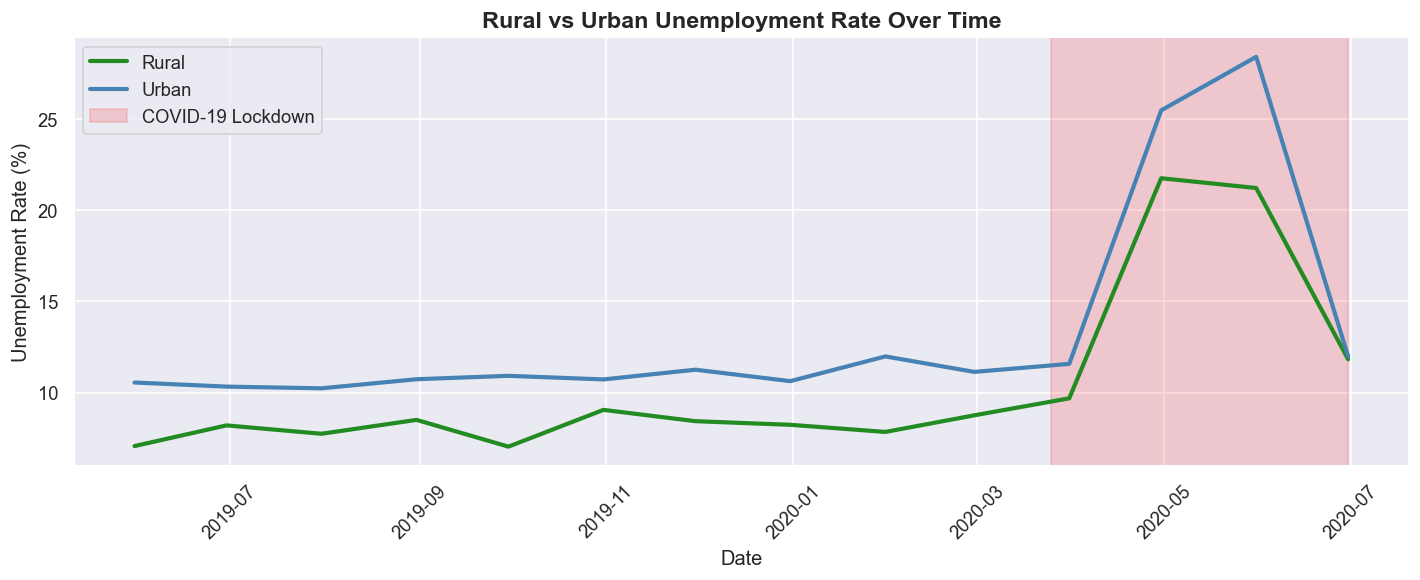

In [23]:
# 7.3  Monthly Rural vs Urban trend
area_monthly = (
    df.groupby(["Date", "Area"])["Unemployment_Rate"]
    .mean()
    .reset_index()
    .sort_values("Date")
)

fig, ax = plt.subplots()
for area, color in zip(["Rural", "Urban"], ["forestgreen", "steelblue"]):
    d = area_monthly[area_monthly["Area"] == area]
    ax.plot(d["Date"], d["Unemployment_Rate"], label=area, color=color, linewidth=2.5)

ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-30"),
           alpha=0.15, color="red", label="COVID-19 Lockdown")
ax.set_title("Rural vs Urban Unemployment Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Unemployment Rate (%)")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 8. COVID-19 Impact Analysis <a id='8-covid-impact'></a>

In [24]:
# 8.1  Define periods
df["Period"] = np.where(
    df["Date"] >= pd.Timestamp("2020-04-01"),
    "During COVID", "Pre-COVID"
)

pre   = df[df["Period"] == "Pre-COVID"]["Unemployment_Rate"].values
covid = df[df["Period"] == "During COVID"]["Unemployment_Rate"].values

print("── COVID-19 Impact (NumPy) ──────────────────────────────")
print(f"  Pre-COVID   — Mean: {np.mean(pre):.2f}%  Std: {np.std(pre):.2f}%")
print(f"  During COVID— Mean: {np.mean(covid):.2f}%  Std: {np.std(covid):.2f}%")
pct = (np.mean(covid) - np.mean(pre)) / np.mean(pre) * 100
print(f"\n  📈 Unemployment INCREASED by {pct:.1f}% during COVID-19 lockdowns")


── COVID-19 Impact (NumPy) ──────────────────────────────
  Pre-COVID   — Mean: 9.61%  Std: 7.37%
  During COVID— Mean: 20.19%  Std: 16.12%

  📈 Unemployment INCREASED by 110.0% during COVID-19 lockdowns


In [25]:
# 8.2  State-wise COVID impact
covid_impact = (
    df.groupby(["Region", "Period"])["Unemployment_Rate"]
    .mean()
    .unstack(fill_value=0)
    .round(2)
)
covid_impact["Change_%"] = (
    (covid_impact["During COVID"] - covid_impact["Pre-COVID"])
    / covid_impact["Pre-COVID"] * 100
).round(1)

print("── State-wise COVID Impact (top 12 most affected) ──────")
covid_impact.sort_values("Change_%", ascending=False).head(12)


── State-wise COVID Impact (top 12 most affected) ──────


Period,During COVID,Pre-COVID,Change_%
Region,,,
Puducherry,57.70,1.58,3551.9
Tamil Nadu,31.74,3.16,904.4
Karnataka,19.16,3.27,485.9
Telangana,18.64,4.77,290.8
Madhya Pradesh,17.76,4.58,287.8
Jharkhand,44.90,13.95,221.9
Andhra Pradesh,15.78,5.21,202.9
Odisha,11.87,3.96,199.7
Kerala,20.94,7.17,192.1


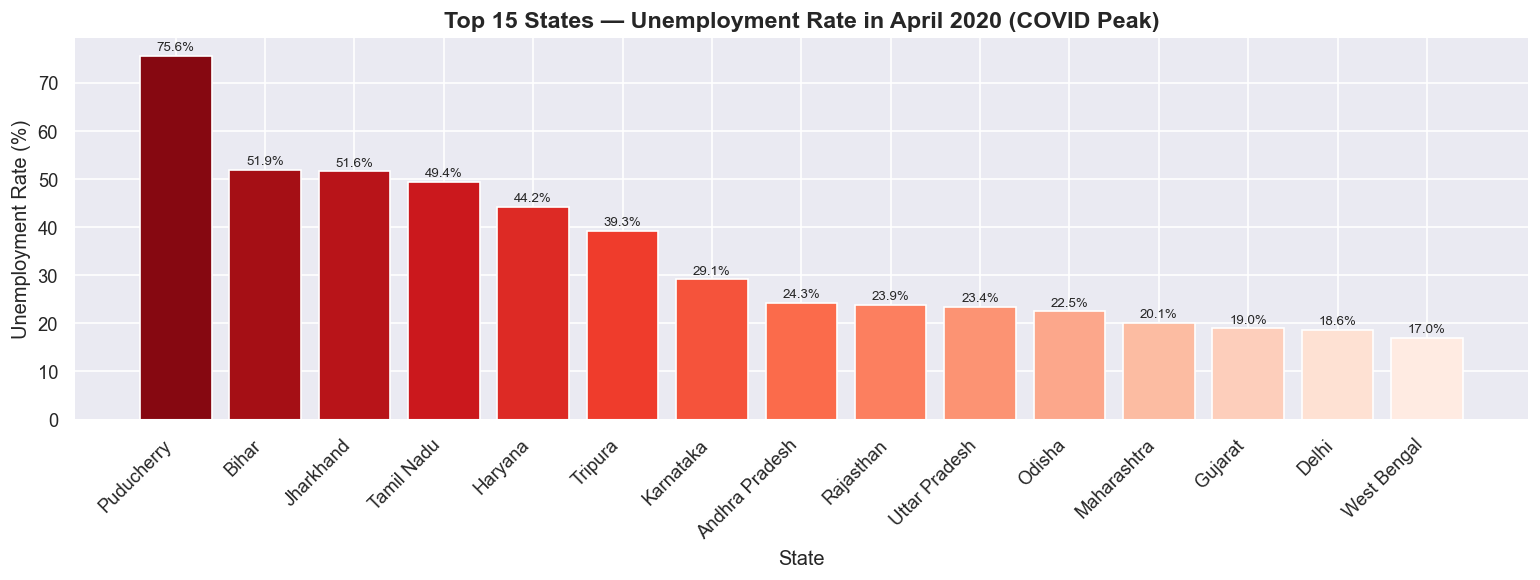

In [26]:
# 8.3  COVID Peak — April 2020 bar chart
apr2020 = (
    df[df["Date"].dt.to_period("M") == "2020-04"]
    .groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

colors = sns.color_palette("Reds_r", len(apr2020))
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(apr2020["Region"], apr2020["Unemployment_Rate"],
              color=colors, edgecolor="white")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_title("Top 15 States — Unemployment Rate in April 2020 (COVID Peak)")
ax.set_xlabel("State"); ax.set_ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()


## 9. Correlation Analysis <a id='9-correlation'></a>

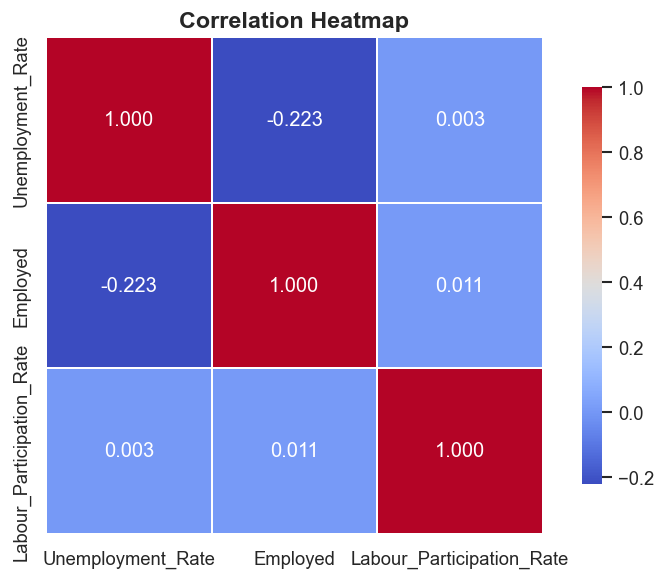


Correlation matrix:
                           Unemployment_Rate  Employed  \
Unemployment_Rate                      1.000    -0.223   
Employed                              -0.223     1.000   
Labour_Participation_Rate              0.003     0.011   

                           Labour_Participation_Rate  
Unemployment_Rate                              0.003  
Employed                                       0.011  
Labour_Participation_Rate                      1.000  


In [27]:
# 9.1  Pandas corr
num_df = df[["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]]
corr   = num_df.corr().round(3)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            square=True, linewidths=1.2, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

print("\nCorrelation matrix:")
print(corr)


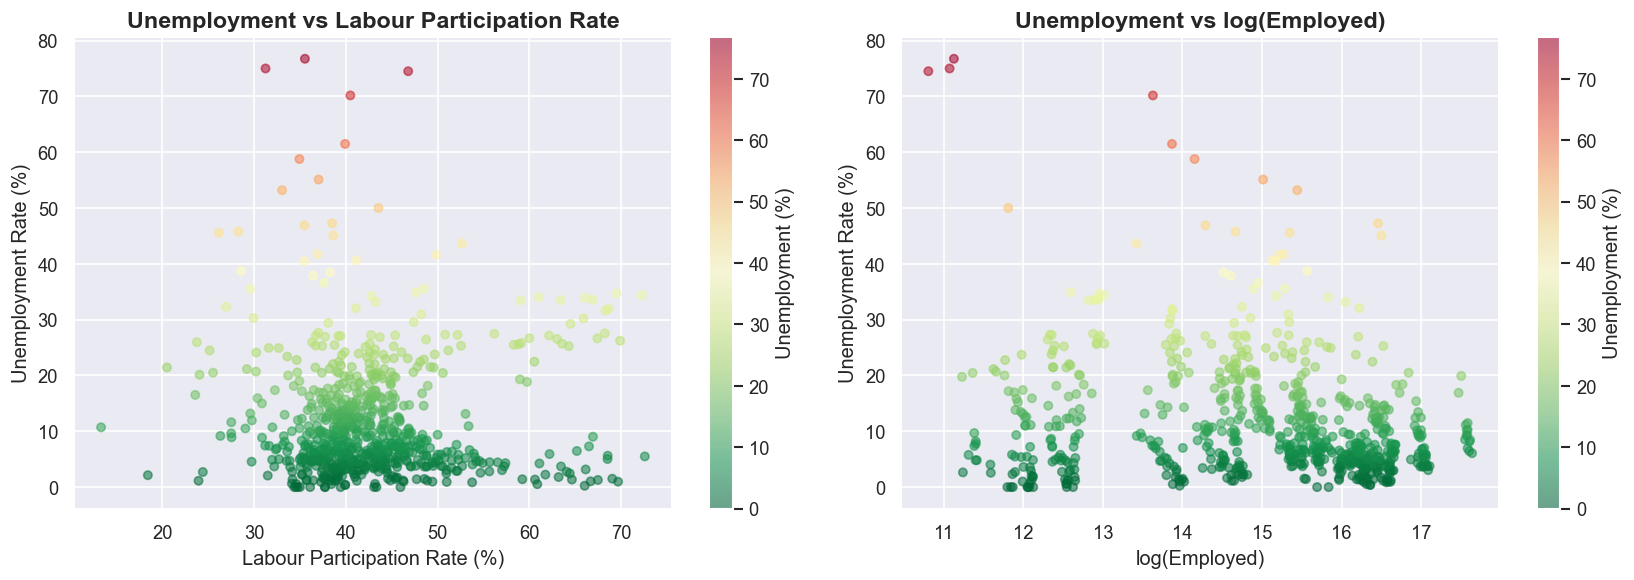

In [28]:
# 9.2  Scatter: Unemployment Rate vs Labour Participation Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(df["Labour_Participation_Rate"], df["Unemployment_Rate"],
                      c=df["Unemployment_Rate"], cmap="RdYlGn_r", alpha=0.55, s=25)
plt.colorbar(sc1, ax=axes[0], label="Unemployment (%)")
axes[0].set_title("Unemployment vs Labour Participation Rate")
axes[0].set_xlabel("Labour Participation Rate (%)")
axes[0].set_ylabel("Unemployment Rate (%)")

sc2 = axes[1].scatter(np.log1p(df["Employed"]), df["Unemployment_Rate"],
                      c=df["Unemployment_Rate"], cmap="RdYlGn_r", alpha=0.55, s=25)
plt.colorbar(sc2, ax=axes[1], label="Unemployment (%)")
axes[1].set_title("Unemployment vs log(Employed)")
axes[1].set_xlabel("log(Employed)")
axes[1].set_ylabel("Unemployment Rate (%)")

plt.tight_layout(); plt.show()


## 10. Visualizations <a id='10-visualizations'></a>

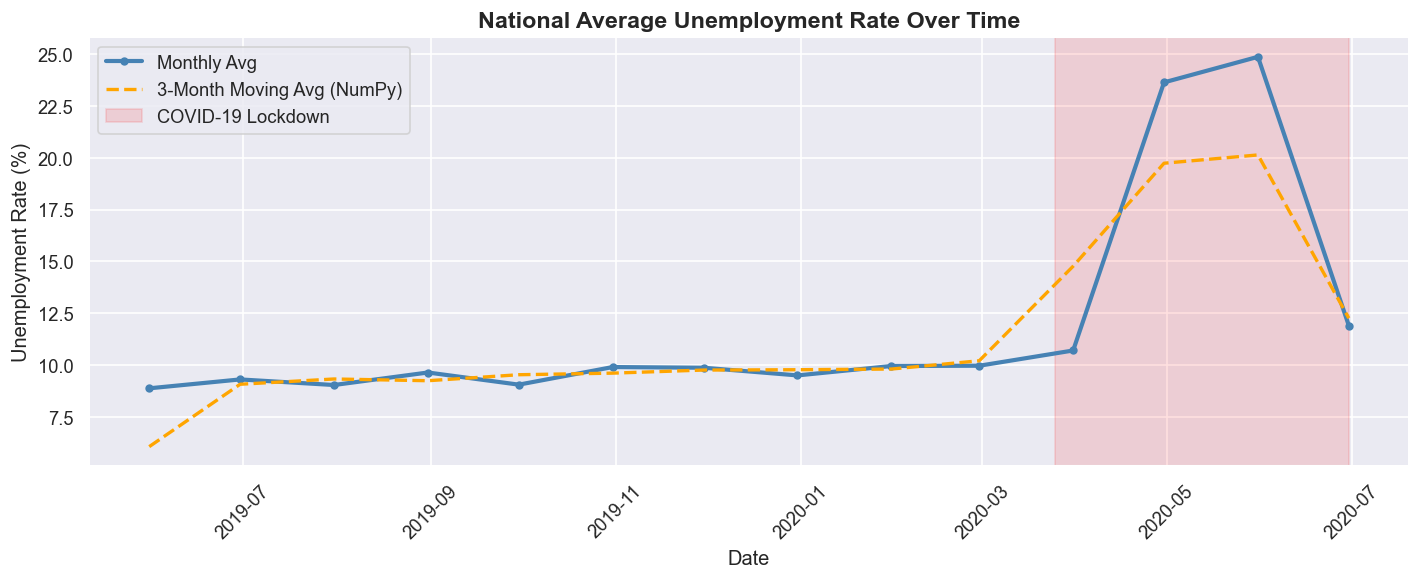

In [29]:
# Chart A ── National Unemployment Trend + Moving Average
vals = monthly_nat["Unemployment_Rate"].values
ma3  = np.convolve(vals, np.ones(3)/3, mode="same")

fig, ax = plt.subplots()
ax.plot(monthly_nat["Date"], vals, color="steelblue", linewidth=2.5,
        marker="o", markersize=4, label="Monthly Avg")
ax.plot(monthly_nat["Date"], ma3, color="orange", linewidth=2,
        linestyle="--", label="3-Month Moving Avg (NumPy)")
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-30"),
           alpha=0.12, color="red", label="COVID-19 Lockdown")
ax.set_title("National Average Unemployment Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Unemployment Rate (%)")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


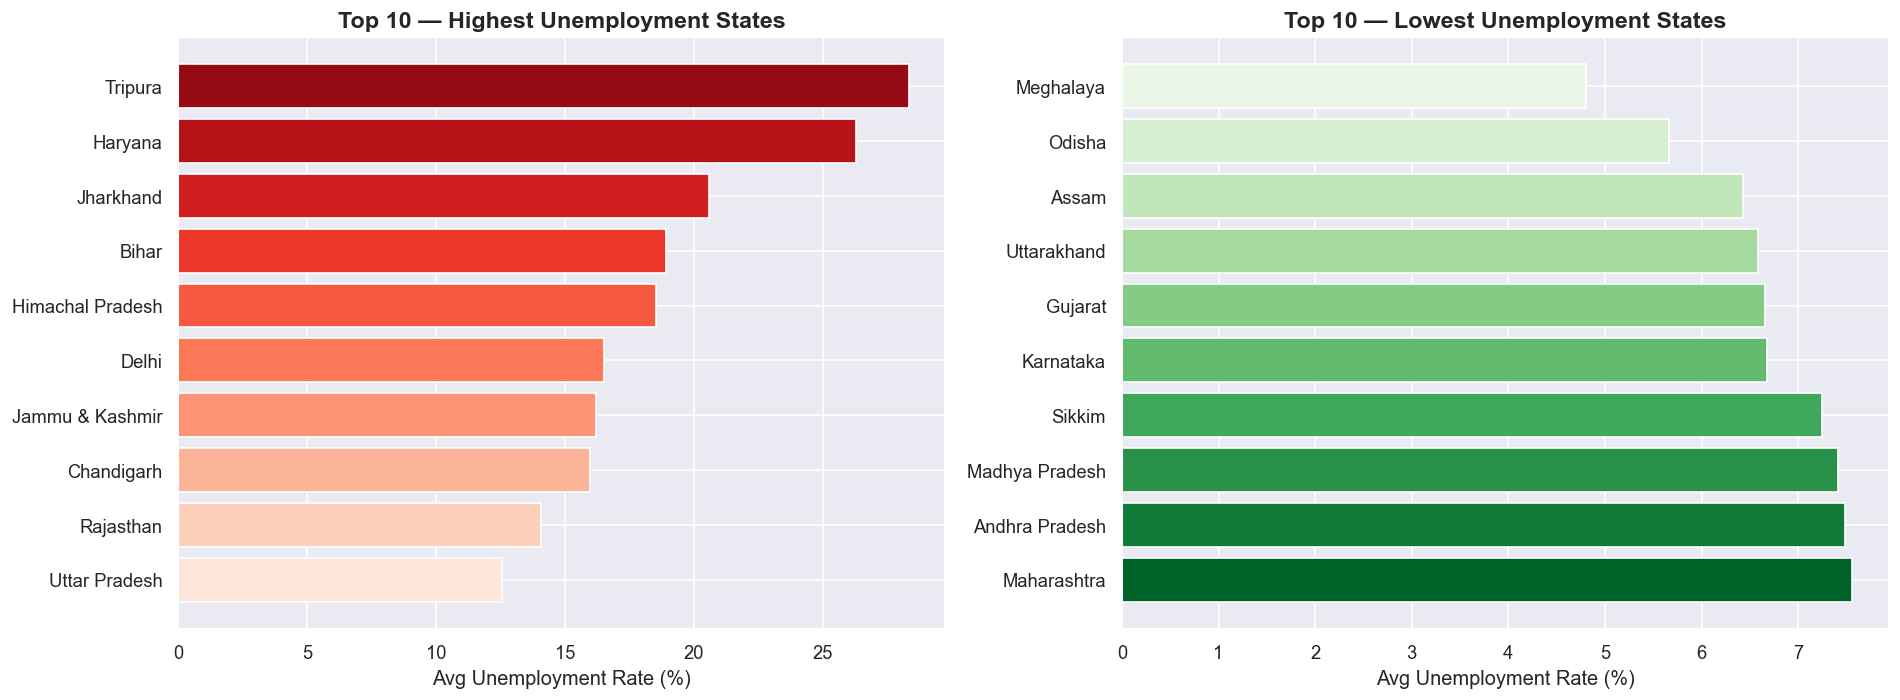

In [30]:
# Chart B ── Top 10 Highest vs Lowest Unemployment States
top10 = region_avg["Avg"].nlargest(10).reset_index()
bot10 = region_avg["Avg"].nsmallest(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top10["Region"], top10["Avg"],
             color=sns.color_palette("Reds_r", 10))
axes[0].set_title("Top 10 — Highest Unemployment States")
axes[0].set_xlabel("Avg Unemployment Rate (%)"); axes[0].invert_yaxis()

axes[1].barh(bot10["Region"], bot10["Avg"],
             color=sns.color_palette("Greens", 10))
axes[1].set_title("Top 10 — Lowest Unemployment States")
axes[1].set_xlabel("Avg Unemployment Rate (%)"); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()


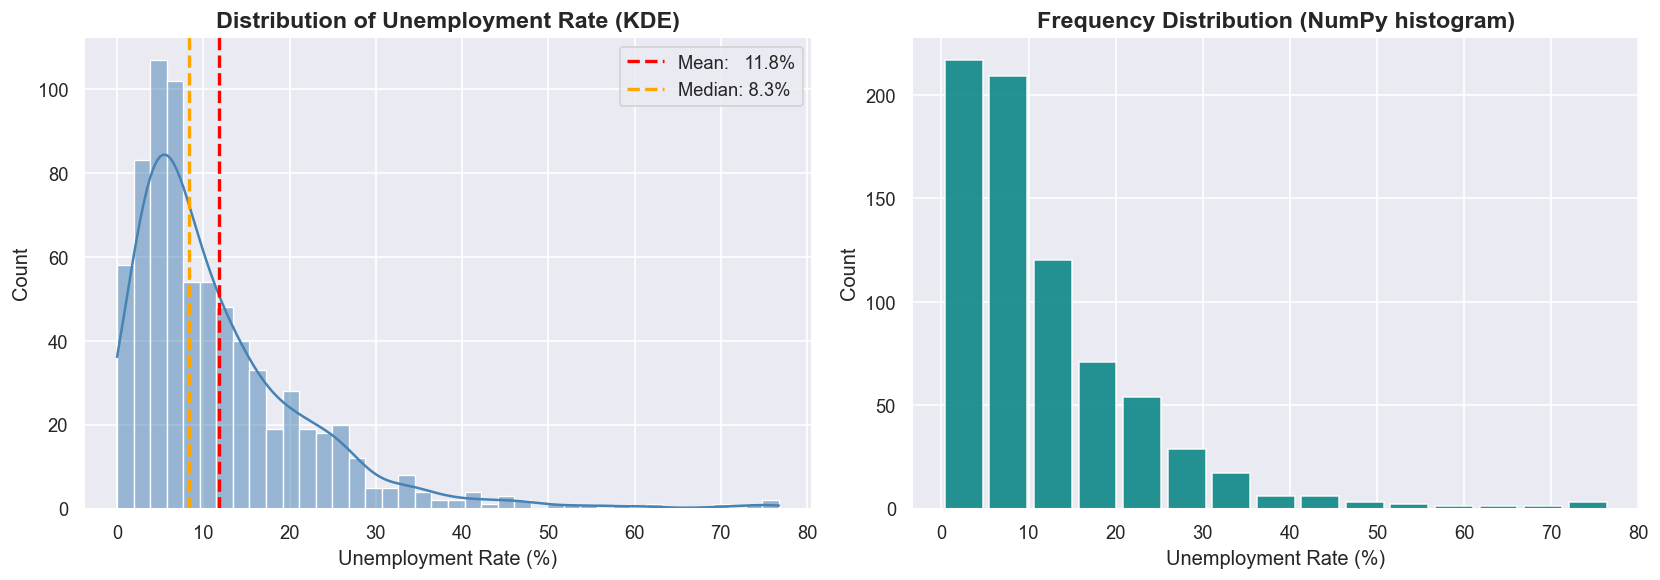

In [31]:
# Chart C ── Distribution with NumPy histogram overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seaborn KDE + histogram
sns.histplot(df["Unemployment_Rate"], bins=40, kde=True,
             color="steelblue", edgecolor="white", ax=axes[0])
axes[0].axvline(np.mean(ur), color="red",   linestyle="--", linewidth=2,
                label=f"Mean:   {np.mean(ur):.1f}%")
axes[0].axvline(np.median(ur), color="orange", linestyle="--", linewidth=2,
                label=f"Median: {np.median(ur):.1f}%")
axes[0].set_title("Distribution of Unemployment Rate (KDE)")
axes[0].set_xlabel("Unemployment Rate (%)"); axes[0].legend()

# NumPy histogram bar chart
counts, edges = np.histogram(ur, bins=15)
centers = (edges[:-1] + edges[1:]) / 2
axes[1].bar(centers, counts, width=np.diff(edges)*0.85,
            color="teal", edgecolor="white", alpha=0.85)
axes[1].set_title("Frequency Distribution (NumPy histogram)")
axes[1].set_xlabel("Unemployment Rate (%)"); axes[1].set_ylabel("Count")

plt.tight_layout(); plt.show()


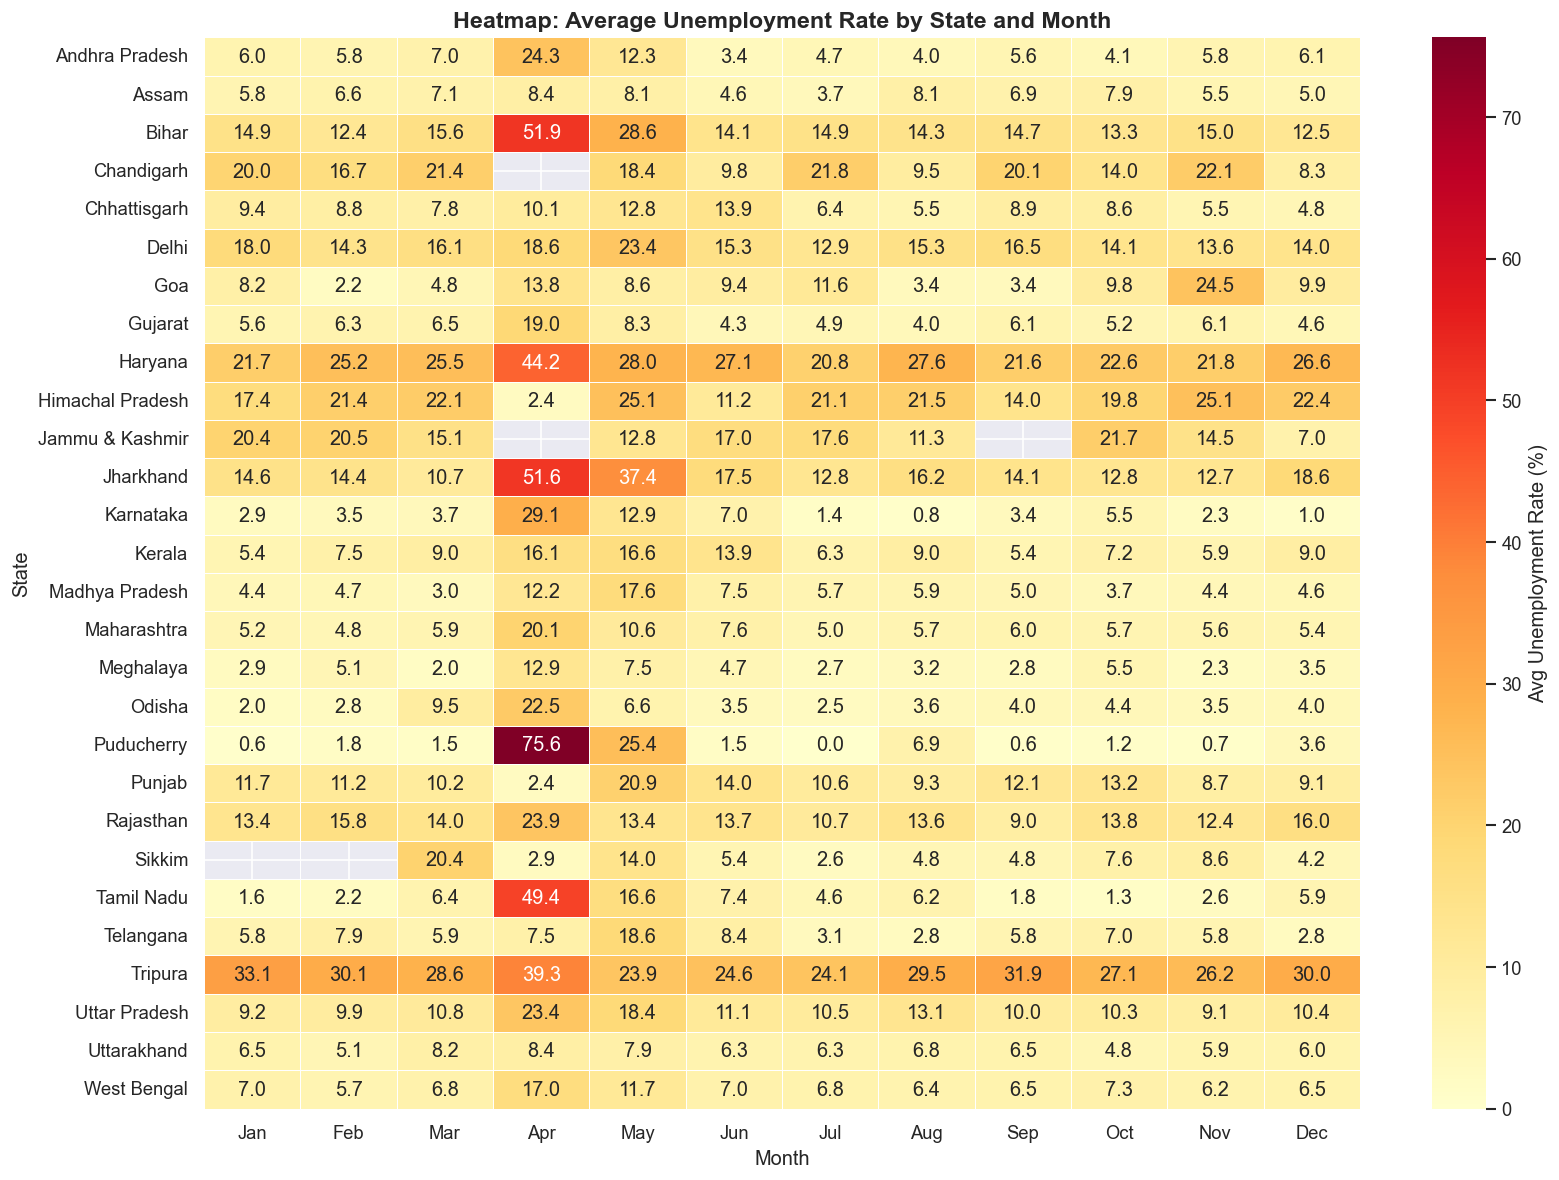

In [32]:
# Chart D ── State × Month Heatmap
heat = (
    df.groupby(["Region", "Month_Num", "Month_Name"])["Unemployment_Rate"]
    .mean()
    .reset_index()
)
pivot = heat.pivot_table(index="Region", columns="Month_Num",
                         values="Unemployment_Rate")
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
pivot.columns = [month_map.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"Avg Unemployment Rate (%)"}, ax=ax)
ax.set_title("Heatmap: Average Unemployment Rate by State and Month")
ax.set_xlabel("Month"); ax.set_ylabel("State")
plt.tight_layout(); plt.show()


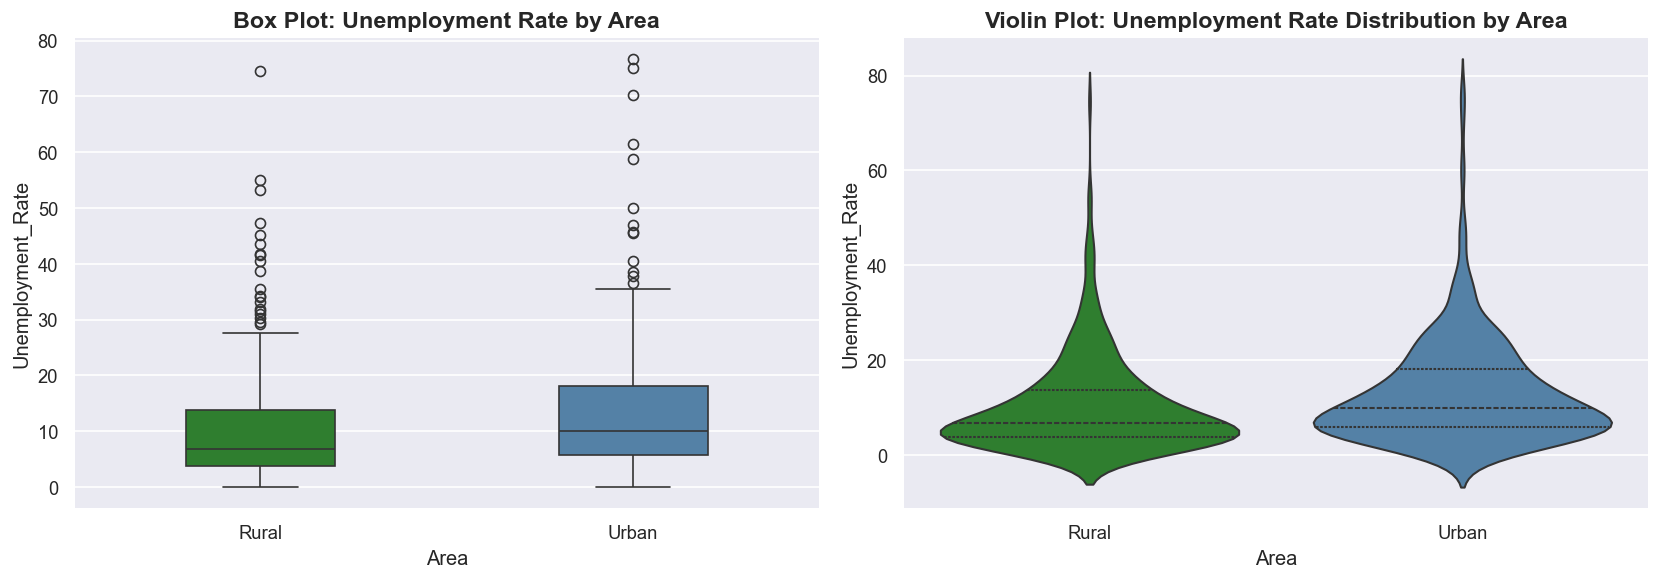

In [33]:
# Chart E ── Box + Violin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Area", y="Unemployment_Rate",
            palette={"Rural":"forestgreen","Urban":"steelblue"},
            width=0.4, ax=axes[0])
axes[0].set_title("Box Plot: Unemployment Rate by Area")

sns.violinplot(data=df, x="Area", y="Unemployment_Rate",
               palette={"Rural":"forestgreen","Urban":"steelblue"},
               inner="quartile", ax=axes[1])
axes[1].set_title("Violin Plot: Unemployment Rate Distribution by Area")

plt.tight_layout(); plt.show()


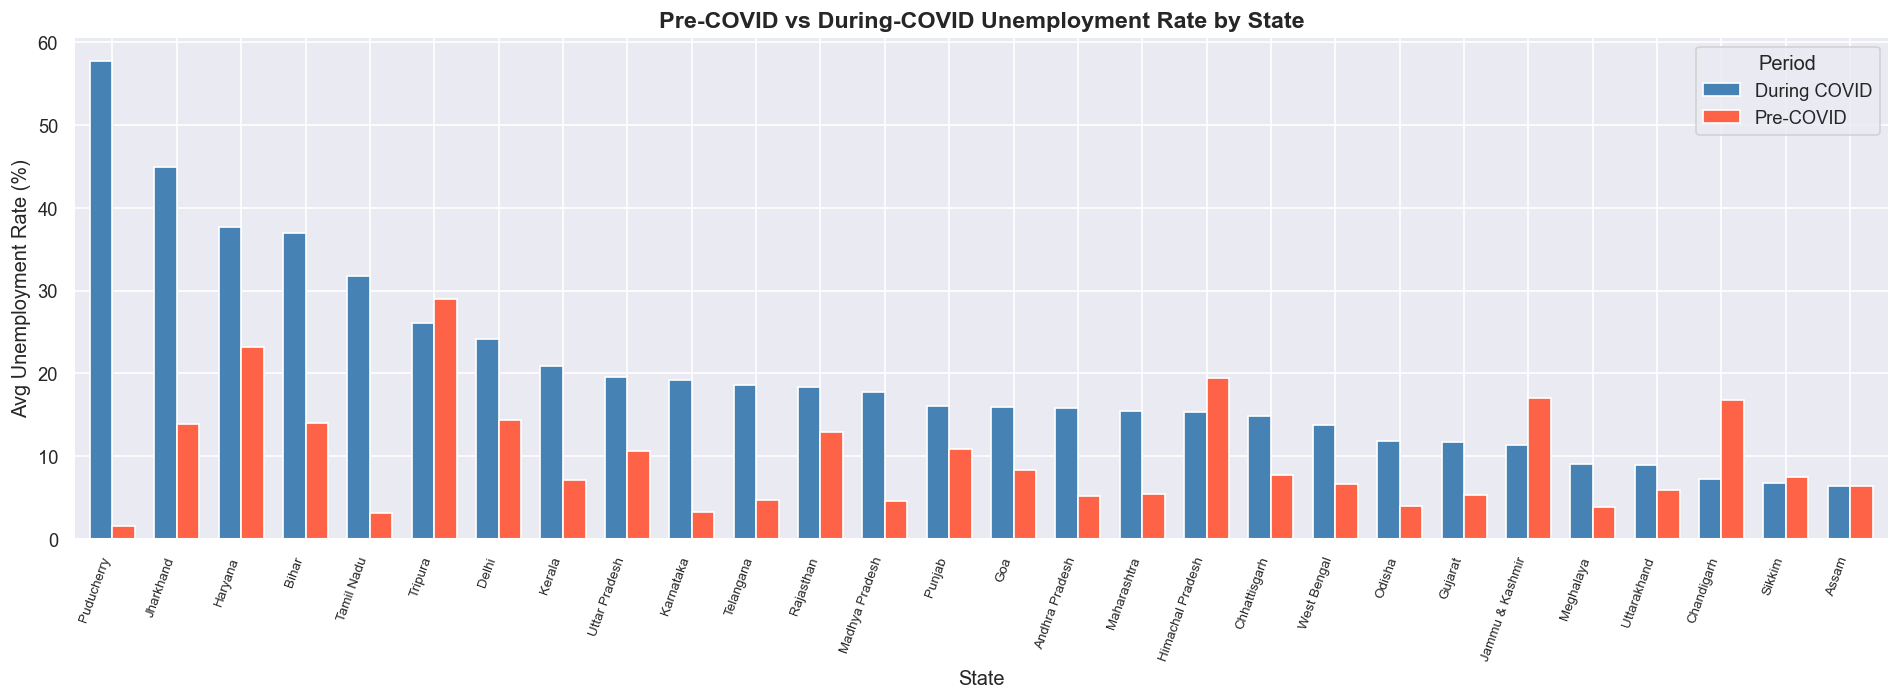

In [34]:
# Chart F ── Pre-COVID vs During-COVID (State-wise grouped bar)
pivot_c = df.groupby(["Region","Period"])["Unemployment_Rate"] \
             .mean().unstack().round(2)

fig, ax = plt.subplots(figsize=(16, 6))
pivot_c.sort_values("During COVID", ascending=False) \
       .plot(kind="bar", ax=ax,
             color=["steelblue","tomato"], edgecolor="white", width=0.7)
ax.set_title("Pre-COVID vs During-COVID Unemployment Rate by State")
ax.set_xlabel("State"); ax.set_ylabel("Avg Unemployment Rate (%)")
ax.legend(title="Period")
plt.xticks(rotation=70, ha="right", fontsize=8)
plt.tight_layout(); plt.show()


## 11. Key Insights & Conclusions <a id='11-conclusions'></a>

In [35]:
pre_mean   = np.mean(df[df["Period"]=="Pre-COVID"]["Unemployment_Rate"].values)
covid_mean = np.mean(df[df["Period"]=="During COVID"]["Unemployment_Rate"].values)
pct_rise   = (covid_mean - pre_mean) / pre_mean * 100

top_state = region_avg["Avg"].idxmax()
low_state = region_avg["Avg"].idxmin()
rural_m   = np.mean(rural)
urban_m   = np.mean(urban)

print("=" * 60)
print("  KEY INSIGHTS & CONCLUSIONS")
print("=" * 60)
print(f"\n  📁 Dataset")
print(f"     Records  : {len(df)}")
print(f"     States   : {df['Region'].nunique()}")
print(f"     Period   : {df['Date'].min().date()} → {df['Date'].max().date()}")

print(f"\n  📊 Overall Statistics (NumPy)")
print(f"     Mean          : {np.mean(ur):.2f}%")
print(f"     Median        : {np.median(ur):.2f}%")
print(f"     Std Deviation : {np.std(ur):.2f}")
print(f"     IQR           : {np.percentile(ur,75)-np.percentile(ur,25):.2f}")

print(f"\n  🗺️  Regional Insights")
print(f"     Highest avg unemployment : {top_state}  ({region_avg.loc[top_state,'Avg']:.2f}%)")
print(f"     Lowest  avg unemployment : {low_state}  ({region_avg.loc[low_state,'Avg']:.2f}%)")

print(f"\n  🌾 Rural vs Urban")
print(f"     Rural avg  : {rural_m:.2f}%")
print(f"     Urban avg  : {urban_m:.2f}%")
print(f"     Difference : {urban_m - rural_m:+.2f}% (Urban higher)")

print(f"\n  🦠 COVID-19 Impact")
print(f"     Pre-COVID avg    : {pre_mean:.2f}%")
print(f"     During-COVID avg : {covid_mean:.2f}%")
print(f"     Increase         : +{pct_rise:.1f}%")

print(f"\n  📌 Conclusions")
print("     1. COVID-19 lockdowns caused a massive unemployment spike.")
print("     2. Urban areas consistently record higher unemployment than Rural.")
print("     3. Bihar, Haryana & Tripura are chronically high-unemployment states.")
print("     4. Southern states like Telangana & Andhra Pradesh fare relatively better.")
print("     5. Unemployment rate is negatively correlated with 'Employed' count.")
print("\n" + "=" * 60)
print("  ✅  Analysis Complete — Ready for GitHub & LinkedIn!")
print("=" * 60)


  KEY INSIGHTS & CONCLUSIONS

  📁 Dataset
     Records  : 740
     States   : 28
     Period   : 2019-05-31 → 2020-06-30

  📊 Overall Statistics (NumPy)
     Mean          : 11.79%
     Median        : 8.35%
     Std Deviation : 10.71
     IQR           : 11.23

  🗺️  Regional Insights
     Highest avg unemployment : Tripura  (28.35%)
     Lowest  avg unemployment : Meghalaya  (4.80%)

  🌾 Rural vs Urban
     Rural avg  : 10.32%
     Urban avg  : 13.17%
     Difference : +2.84% (Urban higher)

  🦠 COVID-19 Impact
     Pre-COVID avg    : 9.61%
     During-COVID avg : 20.19%
     Increase         : +110.0%

  📌 Conclusions
     1. COVID-19 lockdowns caused a massive unemployment spike.
     2. Urban areas consistently record higher unemployment than Rural.
     3. Bihar, Haryana & Tripura are chronically high-unemployment states.
     4. Southern states like Telangana & Andhra Pradesh fare relatively better.
     5. Unemployment rate is negatively correlated with 'Employed' count.

  ✅  